# 1. Data Profiling

## Load Insurance Fraud data

In [4]:
# import pandas library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [6]:
# from google.colab import drive

# drive.mount('/content/drive')

NameError: name 'drive' is not defined

In [3]:
# Load data from Google drive
df = pd.read_csv('insurance_fraud.csv')
# df = pd.read_csv('/content/drive/My Drive/WIDS/insurance_fraud.csv')

# Display the first 5 rows of the data
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'insurance_fraud.csv'

### Data Dictionary
| Accenture Data and AI   | Variable Name        | Format   | Possible_Values                                                                                                 | Description                                                                             |
|:------------------------|:---------------------|:-------------|:----------------------------------------------------------------------------------------------------------------|:--------------------------------------------------------------------------------------|
| 1                       | Month                | Character    | Jan, Feb, Mar, Apr, May, Jun, Jul, Aug, Sep, Oct, Nov, Dec                                                      | The month the accident happened                                                       |
| 2                       | Make                 | Character    | Honda, Toyota, Chevrolet, Accura, Mazda, Pontiac, BMW, Dodge, Ford, Mercedes, Mercury, Nissan, Saab, Saturn, VW | The make of the vehicle the claim was for                                             |
| 3                       | AccidentArea         | Character    | Urban, Rural                                                                                                    | The type of geographical area the accident happened in                                |
| 4                       | MonthClaimed         | Character    | Jan, Feb, Mar, Apr, May, Jun, Jul, Aug, Sep, Oct, Nov, Dec                                                      | The month the claim was made in                                                       |
| 5                       | Sex                  | Character    | Male, Female                                                                                                    | The sex of the person who made the claim                                              |
| 6                       | MaritalStatus        | Character    | Married, Widow, Divorced, Single                                                                                | The marital status of the person who made the claim                                   |
| 7                       | Fault                | Character    | Policy Holder, Third Party                                                                                      | The person who is at fault in the claim                                               |
| 8                       | VehicleCategory      | Character    | Sedan, Sport, Utility                                                                                           | The category of the vehicle the claim was made for                                    |
| 9                       | VehiclePrice         | Numeric      | 100 to 100000                                                                                                   | The price of the vehicle the claim was made for                                       |
| 10                      | Deductible           | Numeric      | 300, 400,500,700                                                                                                | The value of the deductible on the policy                                             |
| 11                      | DriverRating         | Numeric      | 1 to 4                                                                                                          | The rating of the driver based off previous policies                                  |
| 12                      | Days_Policy_Accident | Character    | none, 1 to 7, 8 to 15, 15 to 30, more than 30                                                                   | The number of days the policy has been active before the accident                     |
| 13                      | Days_Policy_Claim    | Character    | none,  8 to 15, 15 to 30, more than 30                                                                          | The number of days the policy has been active before the claim                        |
| 14                      | PastNumberOfClaims   | Character    | none, 1, 2 to 4, more than 4                                                                                    | The past number of claims of the owner of the policy                                  |
| 15                      | AgeOfPolicyHolder    | Character    | 25 and under, over 25                                                                                           | The age of the policy holder in bins                                                  |
| 16                      | PoliceReportFiled    | Character    | Yes, No                                                                                                         | Field if the accident was reported to the police                                      |
| 17                      | WitnessPresent       | Character    | Yes, No                                                                                                         | Field if there was a witness present for the accident                                 |
| 18                      | AgentType            | Character    | External, Internal                                                                                              | The type of insurance agent for the claim                                             |
| 19                      | AddressChange_Claim  | Character    | under 6 months, 1 year, 2 to 3 years, 4 to 8 years, no change                                                   | The time since the last change of address for policy holder at time of claim          |
| 20                      | NumberOfCars         | Character    | 1 vehicle, 2 vehicles, 3 to 4, 5 to 8                                                                           | The number of cars involved in the accident being claimed on                          |
| 21                      | BasePolicy           | Character    | All Perils, Collision, Liability                                                                                | The Base Insurance Policy type                                                        |
| 22                      | FraudFound_P         | Numeric      | 0 , 1                                                                                                           | Binary if the claim was fraudulent (1 indicates fraud was found in the investigation) |
| 23                      | RegistrationDate     | DateTime     | Any DateTime in form DD/MM/YY HH:MM:SS                                                                          | The date and time of registration of the vehicle                                      |
| 24                      | Year                 | Numeric      | 2023                                                                                                            | Year that claim was made                                                              |
| 25                      | PolicyNumber         | Numeric      | Any number                                                                                                      | ID of the insurance policy associated with the case                                   |

## Remove Duplicate Rows

In [ ]:
lenBefore = len(df)

# Drop duplicates
df = df.drop_duplicates()

lenAfter = len(df)

print("We have removed " + str(lenBefore-lenAfter) + " duplicates.")
print("Now, we have " + str(lenAfter) + " rows.")



## Data Exploration

In [ ]:
# List the unique value for each column
for column in df.columns:
    unique_values = df[column].unique()
    print(f"'{column}' -  {unique_values}")

In [ ]:
# Count the NaN value for each column
nan_counts = df.isnull().sum()
print(nan_counts)

In [ ]:
# Get summary stats of the table
df.describe()

## Eliminating unuseful column
Registration Date, Policy Number, Make, Sex, Vehicle Category, Marital Status, Year, Age of the Policy Holder, Agent Type are not relevant to our goal.

In [ ]:
df = df.drop(columns = ['PolicyNumber','Year','RegistrationDate','Make','Sex','VehicleCategory','MaritalStatus','AgeOfPolicyHolder','AgentType'])

### Data Format Standardization according to the data dictionary

1. "PoliceReportFiled" column: Distribute each existing unique value evenly among these NaN values

In [ ]:
def fill_na_with_distribution(df, column_name):
    unique_values = df[column_name].dropna().unique() # Find unique values
    nan_count = df[column_name].isna().sum() # Count nan value
    values_per_unique_value = nan_count // len(unique_values) # Determine how many NaNs each unique value should be assigned to, ensuring as even a distribution as possible.

    # Assign values
    replacement_values = []
    for value in unique_values:
        replacement_values.extend([value] * values_per_unique_value)

    # Handle the remaining NaNs if they can't be evenly distributed
    remainder = nan_count % len(unique_values)
    if remainder > 0:
        additional_values = np.random.choice(unique_values, size=remainder, replace=False)
        replacement_values.extend(additional_values)

    # Replace NaNs
    nan_indices = df[column_name][df[column_name].isna()].index[:len(replacement_values)]
    df.loc[nan_indices, column_name] = replacement_values

fill_na_with_distribution(df, 'PoliceReportFiled')

2. "Deductible" column: replace the Nan value with the mean value of deductible

In [ ]:
df.fillna({'Deductible':408}, inplace=True)

3. “DriverRating” column: replace the Nan value with the mean value of Drive rating and replace -2 to 2

In [ ]:
df['DriverRating'] = pd.to_numeric(df['DriverRating'])
df.fillna({'DriverRating':2.0}, inplace=True)
df['DriverRating'] = df['DriverRating'].replace(-2, 2)

4. "WitnessPresent" column: Distribute each existing unique value evenly among these NaN values

In [ ]:
fill_na_with_distribution(df, 'WitnessPresent')

5.“FraudFound_P": Drop the Nan Value

In [ ]:
df=df.dropna(subset=['FraudFound_P'])


6. Month -> number

In [ ]:
from datetime import datetime

def month_to_number(month_str):
    return datetime.strptime(month_str, '%b').month

df['Month'] = df['Month'].apply(month_to_number)
df['MonthClaimed'] = df['MonthClaimed'].apply(month_to_number)

## Outliers

In [ ]:
df[['VehiclePrice']].boxplot(figsize=(12, 8))


In [ ]:
# mean value below 400000
mean_value = int(round(df.loc[df['VehiclePrice'] <= 400000, 'VehiclePrice'].mean()))

# replace with mean value
df.loc[df['VehiclePrice'] > 400000, 'VehiclePrice'] = mean_value

## Cross-tabulating Fields

In [ ]:
# Single category
df['FraudFound_P'].value_counts()

In [ ]:
# Multiple categories
df_crosstab = pd.crosstab(df['FraudFound_P'], df['WitnessPresent'], margins = False)
df_crosstab

In [ ]:
df_crosstab = pd.crosstab(df['FraudFound_P'], df['PoliceReportFiled'], margins = False)
df_crosstab

In [ ]:
df_crosstab = pd.crosstab(df['FraudFound_P'], df['Fault'], margins = False)
df_crosstab

In [ ]:
df_crosstab = pd.crosstab(df['FraudFound_P'], df['Deductible'], margins = False)
df_crosstab


In [ ]:
df_crosstab = pd.crosstab(df['FraudFound_P'], df['DriverRating'], margins = False)
df_crosstab


In [ ]:
from scipy.stats import chi2_contingency

def chi_square_analysis(df_crosstab):

    # Perform the Chi-squared test
    chi2, p, dof, expected = chi2_contingency(df_crosstab)
    # Calculate the total frequency
    n = df_crosstab.sum().sum()
    # Calculate phi squared
    phi2 = chi2 / n
    r, k = df_crosstab.shape
    # Adjust phi squared
    phi2_corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    r_corr = r - ((r-1)**2)/(n-1)
    k_corr = k - ((k-1)**2)/(n-1)
    # Calculate Cramer's V
    cramer_v = np.sqrt(phi2_corr / min((k_corr-1), (r_corr-1)))


    print(f"Chi-squared Test Statistic: {chi2}")
    print(f"p-value: {p}")
    print(f"Cramer's V: {cramer_v}")

chi_square_analysis(df_crosstab)

there is a statistically significant association between Police report and fraud, as evidenced by the Chi-squared test statistic and the extremely low p-value.

However, the Cramer's V value suggests that the strength of this association is relatively weak.

This means that, while the variables are not independent, the effect size of their relationship is modest.

In [ ]:
df['PoliceReportFiled'] = df['PoliceReportFiled'].map({'Yes': 1, 'No': 0})
df['WitnessPresent'] = df['WitnessPresent'].map({'Yes': 1, 'No': 0})

correlation = df['FraudFound_P'].corr(df['PoliceReportFiled'])
correlation2 = df['FraudFound_P'].corr(df['WitnessPresent'])
print(f"The Pearson correlation coefficient between columns f and police is: {correlation}")
print(f"The Pearson correlation coefficient between columns w and police is: {correlation2}")

So, Police report filed has a little stronger negative linear relationship than witness present. Thus we will drop witness present.

In [ ]:
df = df.drop(columns = ['WitnessPresent'])

## New dataset

In [ ]:
df.head(5)

,Month,AccidentArea,MonthClaimed,Fault,VehiclePrice,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,PoliceReportFiled,AddressChange_Claim,NumberOfCars,BasePolicy,FraudFound_P
0,7,Urban,9,Policy Holder,96494,400.0,1.0,more than 30,more than 30,none,0,no change,1 vehicle,All Perils,1.0
1,7,Rural,1,Policy Holder,89807,400.0,4.0,more than 30,more than 30,none,0,no change,1 vehicle,Collision,1.0
2,7,Urban,8,Policy Holder,25517,400.0,2.0,more than 30,more than 30,none,0,no change,1 vehicle,Collision,1.0
3,11,Urban,1,Policy Holder,70903,400.0,3.0,more than 30,more than 30,none,0,no change,1 vehicle,Collision,1.0
4,11,Urban,1,Policy Holder,28016,400.0,2.0,more than 30,more than 30,1,0,no change,1 vehicle,Collision,1.0


In [ ]:
for column in df.columns:
    unique_values = df[column].unique()
    print(f"'{column}' -  {unique_values}")

'Month' -  [ 7 11 12  1  8  2  3  6  4  5 10  9]
'AccidentArea' -  ['Urban' 'Rural']
'MonthClaimed' -  [ 9  1  8 12  5 11  2  4  3 10  7  6]
'Fault' -  ['Policy Holder' 'Third Party']
'VehiclePrice' -  [96494 89807 25517 ... 37556 34145 14796]
'Deductible' -  [400. 500. 700. 300. 408. 379. 391. 354. 321. 380. 310. 333. 311. 320.
 322. 324. 377. 355.]
'DriverRating' -  [1. 4. 2. 3.]
'Days_Policy_Accident' -  ['more than 30' 'none' '1 to 7' '8 to 15' '15 to 30']
'Days_Policy_Claim' -  ['more than 30' '8 to 15' '15 to 30' 'none']
'PastNumberOfClaims' -  ['none' '1' 'more than 4' '2 to 4']
'PoliceReportFiled' -  [0 1]
'AddressChange_Claim' -  ['no change' 'under 6 months' '4 to 8 years' '2 to 3 years' '1 year']
'NumberOfCars' -  ['1 vehicle' '2 vehicles' '3 to 4' '5 to 8' 'more than 8']
'BasePolicy' -  ['All Perils' 'Collision' 'Liability']
'FraudFound_P' -  [1. 0.]


## Data Visualization

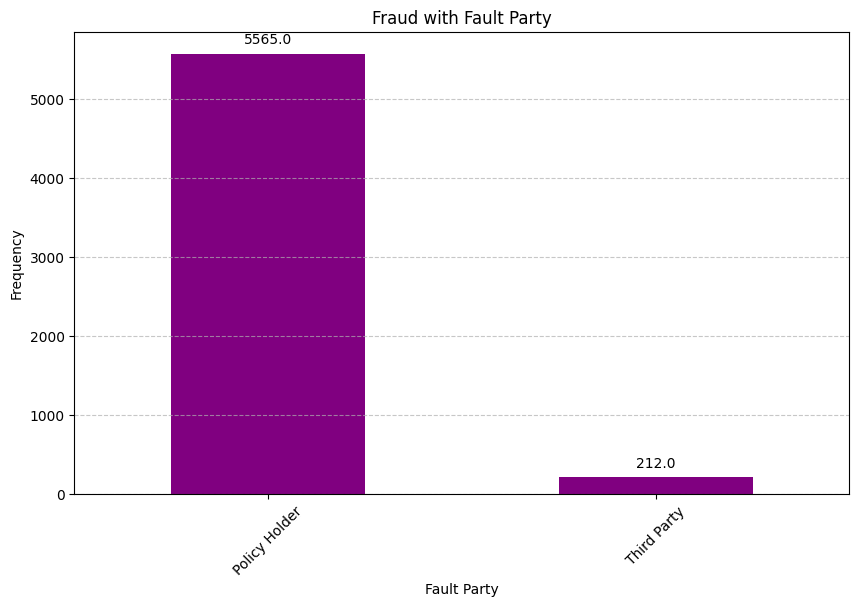

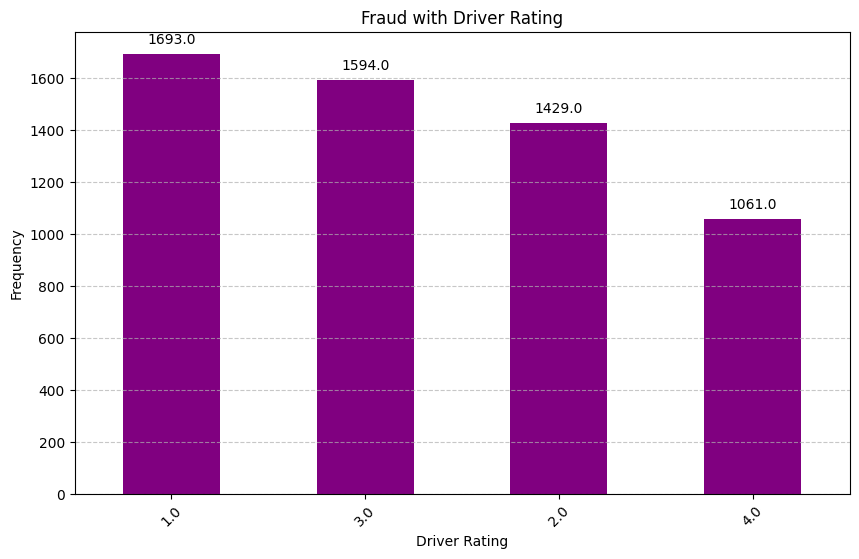

In [ ]:
def plot_relation_fraud(df,fraud_column,cause_column,Title):
    fraud_df = df[df[fraud_column] == 1][cause_column].value_counts()

    plt.figure(figsize=(10, 6))
    bars = fraud_df.plot(kind='bar', color='purple')
    plt.title('Fraud with ' + Title )
    plt.xlabel(Title)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    for p in bars.patches:
        bars.annotate(format(p.get_height(), '.1f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 10),
                        textcoords = 'offset points')
    plt.show()

plot_relation_fraud(df,'FraudFound_P','Fault','Fault Party')
plot_relation_fraud(df,'FraudFound_P','DriverRating','Driver Rating')

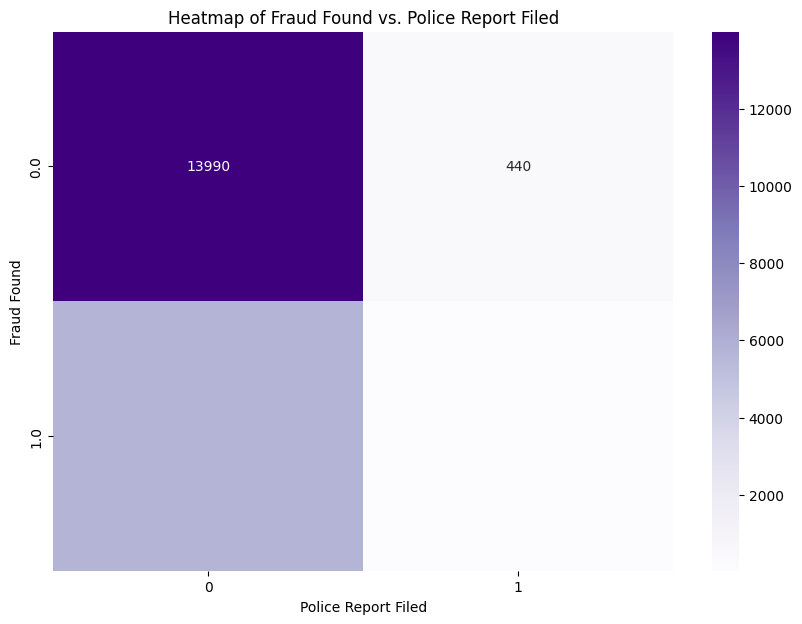

In [ ]:
df_crosstab = pd.crosstab(df['FraudFound_P'], df['PoliceReportFiled'], margins = False)
df_crosstab

# Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df_crosstab, annot=True, cmap='Purples', fmt='d')
plt.title('Heatmap of Fraud Found vs. Police Report Filed')
plt.ylabel('Fraud Found')
plt.xlabel('Police Report Filed')
plt.show()


## Split and save the Dataset: Train, Test, Validation

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_test_df = train_test_split(df, test_size=0.4, random_state=42)

test_df, val_df = train_test_split(temp_test_df, test_size=0.5, random_state=42)



In [ ]:
# Display the shape of train, valid and test sets.
print(train_df.shape)
print(test_df.shape)
print(val_df.shape)

(12124, 15)
(4041, 15)
(4042, 15)


In [ ]:
# Save the data as separate csv files.
train_df.to_csv('train.csv', index=False)
val_df.to_csv('valid.csv', index=False)
test_df.to_csv('test.csv', index=False)

### Assign X and y for later numeric representation and model training

In [ ]:
# Load the train.csv
train = pd.read_csv("train.csv")

# Assign X train and y train
X_train = train.drop('FraudFound_P', axis=1)
y_train = train['FraudFound_P']

#Display the shape of X_train.
X_train.shape

(12124, 14)

In [ ]:
X_train.head(5)

,Month,AccidentArea,MonthClaimed,Fault,VehiclePrice,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,PoliceReportFiled,AddressChange_Claim,NumberOfCars,BasePolicy
0,4,Urban,4,Policy Holder,34500,400.0,1.0,more than 30,more than 30,2 to 4,0,no change,1 vehicle,Liability
1,4,Urban,5,Policy Holder,28411,400.0,3.0,more than 30,more than 30,1,0,no change,1 vehicle,Collision
2,1,Urban,1,Third Party,23471,400.0,1.0,more than 30,more than 30,none,0,no change,1 vehicle,Collision
3,4,Urban,4,Third Party,22333,400.0,4.0,more than 30,more than 30,2 to 4,0,no change,1 vehicle,Liability
4,8,Urban,9,Third Party,28725,400.0,1.0,more than 30,more than 30,more than 4,0,no change,1 vehicle,Liability


## Encoding

### Label Encoding
More appropriate for ordinal variables where the categories have a natural order

'Days_Policy_Accident','Days_Policy_Claim','PastNumberOfClaims','AddressChange_Claim','NumberOfCars','AccidentArea',  'Fault', 'PoliceReportFiled', 'BasePolicy'

In [ ]:
columns_to_encode = ['Days_Policy_Accident','Days_Policy_Claim','PastNumberOfClaims','AddressChange_Claim','NumberOfCars','AccidentArea',  'Fault', 'PoliceReportFiled', 'BasePolicy']
le = LabelEncoder()
for column in columns_to_encode:
    X_train[column] = le.fit_transform(X_train[column])

X_train.head(5)

,Month,AccidentArea,MonthClaimed,Fault,VehiclePrice,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,PoliceReportFiled,AddressChange_Claim,NumberOfCars,BasePolicy
0,4,1,4,0,34500,400.0,1.0,3,2,1,0,3,0,2
1,4,1,5,0,28411,400.0,3.0,3,2,0,0,3,0,1
2,1,1,1,1,23471,400.0,1.0,3,2,3,0,3,0,1
3,4,1,4,1,22333,400.0,4.0,3,2,1,0,3,0,2
4,8,1,9,1,28725,400.0,1.0,3,2,2,0,3,0,2


In [ ]:
X_train.shape

(12124, 14)

In [ ]:
y_train.shape

(12124,)

**Function to encoding**

In [ ]:
# columns_to_onehot = ['Make',AccidentArea', 'Sex', 'MaritalStatus', 'Fault', 'VehicleCategory', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'BasePolicy']
# columns_to_labelencode = ['Days_Policy_Accident', 'Days_Policy_Claim', 'AgeOfPolicyHolder', 'PastNumberOfClaims', 'AddressChange_Claim', 'NumberOfCars']

# def preprocess_data(X, columns_to_onehot, columns_to_labelencode):
#     X_onehot = pd.get_dummies(X[columns_to_onehot])
#     X_onehot = X_onehot * 1
#     le = LabelEncoder()
#     for column in columns_to_labelencode:
#         X[column] = le.fit_transform(X[column])
#     X_modified = X.drop(columns_to_onehot, axis=1)
#     X = pd.concat([X_modified, X_onehot], axis=1)
#     return X

Support Vector Machine (SVM), Random-Forest (RF), Decision-Tree (DT), Adaboost, K-Nearest Neighbor (KNN), Linear Regression (LR), Naïve Bayes (NB), and Multi-Layer Perceptron (MLP)